In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase.io import read
from ase import Atoms

from pathlib import Path

O objetivo deste Notebook, será o de verificar se o filtro de 20 eV/Ang funcionaria para o ænet convencional

In [2]:
# Paths
# train        = 6254 estruturas (Original Sampling)
# subset1      = 221  (1x1x8)
# subset2      = 49   (2x1x4)
# subset3      = 78   (3x3x3)
# normal_modes = 10
# -----------------------------------
# 6612 estruturas.

data = Path("/home/jvc/ZnO_database/data")

train = data / "dataset" / "01_LDA_dataset" 
subsets_names = [
    "LDA_118_XSF",
    "LDA_214_XSF",
    "LDA_333_XSF",
    "LDA_normal_modes_3x3x3",
]

subsets: list[Path] = [data / f"subsets/{s}" for s in subsets_names]
xsf_dirs: list[Path] = [train, *subsets]
all_files: list[Path] = [file for d in xsf_dirs for file in sorted(d.glob("*.xsf"))]
atoms = [read(f) for f in all_files]

In [3]:
print(*all_files[:5], sep="\n")
print(len(all_files))

/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0002-ZnO-112-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0003-ZnO-113-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0004-ZnO-211-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0005-ZnO-212-fa0.90-fc0.90-n0.000.xsf
6602


In [4]:
def get_force_df(atoms: list[Atoms], filenames: list[Path]) -> pd.DataFrame:
    """Return a long dataframe containing all the forces acting on a list of atoms."""

    dados_forcas = []

    for i, snapshot in enumerate(atoms):
        forces = snapshot.get_forces()

        for idx_atomo, vetor_forca in enumerate(forces):
            symbols: list[str] = snapshot.get_chemical_symbols()
            dados_forcas.append({
                "filepath": filenames[i],  # Número do snapshot (0, 1, 2...)
                "atom": symbols[idx_atomo],  # Índice do átomo dentro do frame
                "fx": vetor_forca[0],
                "fy": vetor_forca[1],
                "fz": vetor_forca[2],
            })

    df_forcas = pd.DataFrame(dados_forcas)
    return df_forcas

In [5]:
forces = get_force_df(atoms=atoms, filenames=all_files)

# Filtro do aenet-PyTorch
forces["atomo_valido"] = (forces.iloc[:, 2:].abs() <= 20).all(axis=1)

print("Amostra do Dataframe filtrando por força no átomo:\n")
display(forces.sample(10))


Amostra do Dataframe filtrando por força no átomo:



,filepath,atom,fx,fy,fz,atomo_valido
66548,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,Zn,-1.038276,-105.324178,-262.021154,False
112428,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,Zn,-2.364304,-10.214849,28.061194,False
18065,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,Zn,-0.000028,-0.000014,0.047561,True
7351,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,O,0.000028,0.000014,-19.306815,True
98710,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,O,-37.535153,-32.567145,0.266399,False
84479,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,O,-4.102339,-4.032271,0.176650,True
58301,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,Zn,6.579473,-12.210076,-3.510324,True
58912,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,Zn,-6.760034,-0.127207,2.461994,True
35383,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,O,45.336612,-39.514820,-51.865347,False
12224,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,Zn,-0.000084,-0.000049,-8.748342,True


In [6]:

df_estruturas = forces.groupby("filepath")[["atomo_valido"]].all().reset_index()
df_estruturas = df_estruturas.rename(columns={"atomo_valido": "estrutura_valida"})


print("Amostra do Dataframe filtrando por estrutura válida:\n")
display(df_estruturas)

Amostra do Dataframe filtrando por estrutura válida:



,filepath,estrutura_valida
0,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,False
1,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,False
2,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,False
3,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,False
4,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,False
...,...,...
6597,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,False
6598,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,False
6599,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,True
6600,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,True


In [7]:
df_estruturas["estrutura_valida"] = df_estruturas["estrutura_valida"].map({
    True: "sim",
    False: "não",
})
display(df_estruturas)

,filepath,estrutura_valida
0,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,não
1,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,não
2,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,não
3,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,não
4,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,não
...,...,...
6597,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,não
6598,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,não
6599,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim
6600,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim


In [8]:
df_validas = df_estruturas.query("estrutura_valida == 'sim' ")
df_validas = df_validas.reset_index(drop=True)
display(df_validas)

,filepath,estrutura_valida
0,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim
1,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim
2,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim
3,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim
4,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim
...,...,...
1463,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim
1464,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim
1465,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim
1466,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim


In [9]:
df_validas["filepath"].to_csv("estruturas_in_20eV.csv", index=False)

Contagem estruturas:
Invalid    5134
Valid      1468
Name: count, dtype: int64



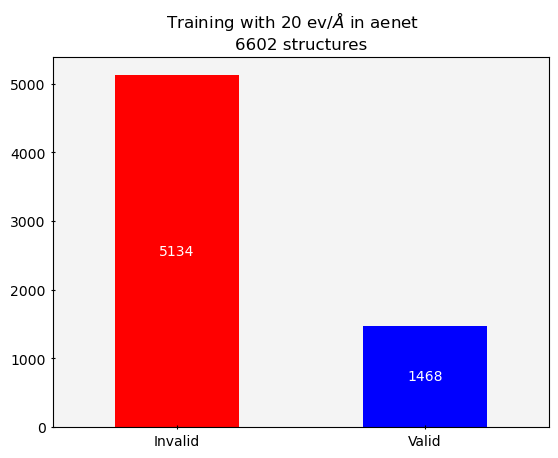

In [10]:
count_estruturas = df_estruturas["estrutura_valida"].value_counts()
count_estruturas.index = ("Invalid", "Valid")

print(f"Contagem estruturas:\n{count_estruturas}\n")

fig, ax = plt.subplots()
fig.suptitle(r"Training with 20 ev/$\AA$ in aenet")
ax.set_title(f"{df_estruturas.shape[0]} structures")
ax.set_facecolor("#f4f4f4")
count_estruturas.plot(kind="bar", ax=ax, rot=0, color=["red", "blue"])
ax.bar_label(container=ax.containers[0], label_type="center", color="white")
ax.tick_params(direction="inout")
plt.show()

In [11]:
df_validas["atoms"] = df_validas["filepath"].apply(lambda x: read(x))
df_validas

,filepath,estrutura_valida,atoms
0,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim,"(Atom('Zn', [-0.0, 1.660782898964, 4.617593095..."
1,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim,"(Atom('Zn', [-0.0, 1.660782898964, 4.617593095..."
2,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim,"(Atom('Zn', [-0.0, 1.660782898964, 4.617593095..."
3,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim,"(Atom('Zn', [-0.0, 1.660782764068, 4.617593520..."
4,/home/jvc/ZnO_database/data/dataset/01_LDA_dat...,sim,"(Atom('Zn', [-0.0, 1.660782764068, 4.617593520..."
...,...,...,...
1463,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim,"(Atom('Zn', [-0.0, 2.01139276126, 16.779000431..."
1464,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim,"(Atom('Zn', [-0.0, 2.01139276126, 16.932936435..."
1465,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim,"(Atom('Zn', [0.0, 2.029845901187, 16.471129334..."
1466,/home/jvc/ZnO_database/data/subsets/LDA_333_XS...,sim,"(Atom('Zn', [0.0, 2.029845901187, 16.779000210..."


In [12]:
# Criando um diretório com cópia dessas estruturas válidas.

import os
import shutil

output_dir = "./estruturas_validas/"

os.makedirs(output_dir, exist_ok=True)

In [13]:
estruturas_validas = df_validas["filepath"].to_list()
estruturas_validas

[PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0066-ZnO-111-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0067-ZnO-112-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0068-ZnO-113-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0069-ZnO-211-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0070-ZnO-212-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0071-ZnO-213-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0072-ZnO-221-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0073-ZnO-222-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0074-ZnO-311-fa0.90-fc1.00-n0.000.xsf'),
 PosixPath('/home/jvc/ZnO_da

In [ ]:
# for filepath in df_validas["filepath"]:
#     shutil.copy(filepath, output_dir)b


In [18]:
training_data = np.loadtxt("train.error", skiprows=1)
training_data

array([[0.000000e+00, 2.948051e-01, 3.556663e-01, 2.936137e-01,
        3.518150e-01],
       [1.000000e+00, 2.948051e-01, 3.556663e-01, 2.936137e-01,
        3.518150e-01],
       [2.000000e+00, 9.528025e-01, 1.028176e+00, 9.814830e-01,
        1.044811e+00],
       ...,
       [9.980000e+02, 2.980453e-04, 4.683994e-04, 5.718073e-04,
        1.493050e-03],
       [9.990000e+02, 2.966824e-04, 4.678502e-04, 5.729108e-04,
        1.498480e-03],
       [1.000000e+03, 2.963230e-04, 4.672801e-04, 5.720119e-04,
        1.497928e-03]])

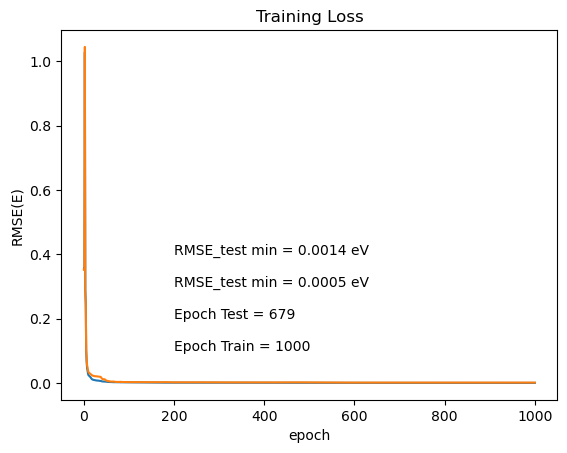

In [42]:
minE_train = training_data[:, 2].min()
minE_test = training_data[:, 4].min()

minE_train_epoch = training_data[:, 2].argmin()
minE_test_epoch = training_data[:, 4].argmin()

plt.title("Training Loss")
plt.xlabel("epoch")
plt.ylabel("RMSE(E)")

plt.plot(training_data[:, 0], training_data[:, 2])
plt.plot(training_data[:, 0], training_data[:, 4])

plt.text(x=200, y=0.1, s=f"Epoch Train = {minE_train_epoch}")
plt.text(x=200, y=0.2, s=f"Epoch Test = {minE_test_epoch}")
plt.text(x=200, y=0.4, s=f"RMSE_test min = {minE_test:.4f} eV")
plt.text(x=200, y=0.3, s=f"RMSE_test min = {minE_train:.4f} eV")


plt.show()